===============================================================================
PIPELINE UNIFICADO DE DATA SCIENCE & NLP - VINAH APP
===============================================================================
Autoras: Ruth & Nati (Equipo de Data Science)
Aplicación: Vinah - Hackathon NoCountry & Alura/Oracle G9

Este notebook integra todo el ciclo de vida del módulo de inteligencia artificial:
- Carga de dataset embebido en memoria (100% auto-contenido).
- Conversión multi-divisa dinámica (ARS, COP, MXN, CLP, USD).
- Limpieza y estandarización a las 8 categorías oficiales.
- Preprocesamiento de texto resistente a mayúsculas, acentos, emojis y símbolos.
- Visualización de datos (EDA) y gráficos de rendimiento del modelo.
- Clasificador NLP (TF-IDF + SGDClassifier) con evaluación detallada (98% precisión).
- Motor Experto Multi-Deuda (Hipotecario, Automotor, Bancario, Tarjetas, Préstamos Personales).
- Exportación del modelo binario (.pkl) y suite de pruebas de ejecución/inferencia para la API (FastAPI) y despliegue en Oracle Cloud (OCI).
===============================================================================

 1: **Carga y exploracion de Datos**

In [1]:
!pip install scikit-learn==1.3.2

In [2]:
import sklearn
print(sklearn.__version__)

1.3.2


In [3]:
!pip install "numpy<2.0.0"

In [4]:
import pandas as pd

df_json = pd.read_json("/content/dataset.json")
df_excel = pd.read_excel("/content/personal_transactions_dashboard_ready.xlsx")
# 2. Unificar
df = pd.concat([df_json, df_excel], ignore_index=True)

# 3. (si hace falta) renombrar columnas
df.rename(columns={
    "Category": "categoria",
    "texto_original": "texto"
}, inplace=True)

# 👇 4. ACÁ agregás los nuevos datos
nuevos = pd.DataFrame([
    ["nafta", "transporte"],
    ["cargar nafta", "transporte"],
    ["ypf nafta", "transporte"],
    ["shell nafta", "transporte"],
    ["estacion de servicio", "transporte"],
    ["combustible auto", "transporte"],
    ["llenar tanque", "transporte"],
], columns=["texto", "categoria"])

df = pd.concat([df, nuevos], ignore_index=True)



In [5]:
print(df.tail(10))

                    Description  Amount     categoria    Month       Date  \
1609                     Sheetz    4.27    Gas & Fuel  2019-09 2019-09-28   
1610                  Starbucks    1.75  Coffee Shops  2019-09 2019-09-30   
1611  Internet Service Provider   75.00      Internet  2019-09 2019-09-30   
1612                        NaN     NaN    transporte      NaN        NaT   
1613                        NaN     NaN    transporte      NaN        NaT   
1614                        NaN     NaN    transporte      NaN        NaT   
1615                        NaN     NaN    transporte      NaN        NaT   
1616                        NaN     NaN    transporte      NaN        NaT   
1617                        NaN     NaN    transporte      NaN        NaT   
1618                        NaN     NaN    transporte      NaN        NaT   

     Transaction Type   Account Name                 texto  
1609            debit  Platinum Card                   NaN  
1610            debit  Platinu

In [6]:
print(df_json.columns)
print(df_excel.columns)

Index(['Description', 'Amount', 'Category', 'Month'], dtype='object')
Index(['Date', 'Description', 'Amount', 'Transaction Type', 'Category',
       'Account Name', 'Month'],
      dtype='object')


In [7]:
print(df.columns)

Index(['Description', 'Amount', 'categoria', 'Month', 'Date',
       'Transaction Type', 'Account Name', 'texto'],
      dtype='object')


In [8]:
df["categoria"].value_counts()

,count
categoria,
Credit Card Payment,286
Groceries,210
Restaurants,162
Utilities,126
Shopping,120
Gas & Fuel,104
Paycheck,92
Home Improvement,72
Coffee Shops,62


##Importacion de dependencias y visualizacion

In [9]:
# [1] Importación de dependencias y visualización
import os
import re
import random
import json
import joblib
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Dependencias cargadas correctamente.')

✅ Dependencias cargadas correctamente.


In [10]:
# [2] Preprocesamiento de texto para la IA
def normalizar_texto_gasto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    texto = re.sub(r'[^a-z0-9\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

In [11]:
# [3] Configuración de categorías y tasas de cambio
TASAS_DE_CAMBIO_LATAM = {
    'ARS': 1200.0,
    'COP': 4000.0,
    'MXN': 18.5,
    'CLP': 940.0,
    'USD': 1.0
}

MAPEO_CATEGORIAS_INGLES_A_OFICIAL = {
    'Groceries': 'alimentacion',
    'Restaurants': 'alimentacion',
    'Coffee Shops': 'alimentacion',
    'Fast Food': 'alimentacion',
    'Food & Dining': 'alimentacion',
    'Shopping': 'ocio y entretenimiento',
    'Music': 'ocio y entretenimiento',
    'Movies & Dvds': 'ocio y entretenimiento',
    'Entertainment': 'ocio y entretenimiento',
    'Alcohol & Bars': 'ocio y entretenimiento',
    'Gas & Fuel': 'transporte',
    'Auto Insurance': 'transporte',
    'Mortgage & Rent': 'vivienda',
    'Home Improvement': 'vivienda',
    'Utilities': 'servicios y comunicaciones',
    'Mobile Phone': 'servicios y comunicaciones',
    'Internet': 'servicios y comunicaciones',
    'Television': 'servicios y comunicaciones',
    'Electronics & Software': 'servicios y comunicaciones',
    'Haircut': 'salud y cuidado',
    'Credit Card Payment': 'obligaciones y ahorro',
    'Paycheck': 'ingresos'
}

def convertir_divisa(valor, moneda_origen='USD', moneda_destino='ARS'):
    try:
        val_float = float(valor)
        m_origen = str(moneda_origen).upper().strip()
        m_destino = str(moneda_destino).upper().strip()

        if m_origen == m_destino:
            return val_float, 1.0

        t_origen = TASAS_DE_CAMBIO_LATAM.get(m_origen, 1.0)
        t_destino = TASAS_DE_CAMBIO_LATAM.get(m_destino, 1200.0)

        if m_origen in ['USD', 'USDT']:
            return val_float * t_destino, t_destino
        elif m_destino in ['USD', 'USDT']:
            return val_float / t_origen, (1.0 / t_origen)
        else:
            valor_usd = val_float / t_origen
            return valor_usd * t_destino, (t_destino / t_origen)
    except Exception:
        return 0.0, 1.0

In [12]:
print("Categorías disponibles:", df['categoria'].nunique())

Categorías disponibles: 23


In [13]:
# [4] Carga e integración del dataset unificado y aumento sintético

# 1. Copia del DataFrame unificado previo (df)
df_unificado = df.copy()

# 2. Mapeo de categorías en inglés respetando categorías que ya están en español
df_unificado['Categoria_Oficial'] = df_unificado['categoria'].map(MAPEO_CATEGORIAS_INGLES_A_OFICIAL).fillna(df_unificado['categoria'])

# 3. Consolidador de descripciones (combina 'texto' y 'Description')
df_unificado['Description'] = df_unificado['texto'].fillna(df_unificado['Description'])

# 4. Filtrar ingresos
df_gastos = df_unificado[df_unificado['Categoria_Oficial'] != 'ingresos'].copy()

# 5. Normalizar valores monetarios
df_gastos['Monto_USD'] = pd.to_numeric(df_gastos['Amount'], errors='coerce').fillna(0.0)
df_gastos['Monto_Local_ARS'] = df_gastos['Monto_USD'].apply(lambda x: convertir_divisa(x, 'USD', 'ARS')[0])

# 6. Aumento sintético balanceado de datos
random.seed(42)
meses_unicos = df_gastos['Month'].dropna().unique() if 'Month' in df_gastos.columns else ['2024-01', '2024-02']

muestras_salud = [
    ('Farmacia Similares compra remedios', 25.0, 'salud y cuidado'),
    ('Consulta medica general sanatorio', 85.0, 'salud y cuidado'),
    ('Tratamiento odontologico dentista', 110.0, 'salud y cuidado'),
    ('Analisis clinicos laboratorio', 45.0, 'salud y cuidado'),
    ('Optica compra de gafas de descanso', 60.0, 'salud y cuidado')
]

muestras_educacion = [
    ('Udemy curso online Data Science', 15.0, 'educacion'),
    ('Compra libro finanzas personales', 25.0, 'educacion'),
    ('Suscripcion Platzi plan anual', 40.0, 'educacion'),
    ('Cuota mensual universidad educacion', 150.0, 'educacion'),
    ('Materiales y utiles de estudio libreria', 20.0, 'educacion')
]

muestras_obligaciones = [
    ('Pago de cuota prestamo bancario', 120.0, 'obligaciones y ahorro'),
    ('Transferencia a fondo de ahorro mensual', 100.0, 'obligaciones y ahorro'),
    ('Inversion plazo fijo banco', 200.0, 'obligaciones y ahorro'),
    ('Pago de impuestos municipales y deudas', 50.0, 'obligaciones y ahorro')
]

nuevos_registros = []
for m in meses_unicos:
    for _ in range(3):
        desc, m_usd, cat = random.choice(muestras_salud)
        nuevos_registros.append({'Description': desc, 'Amount': m_usd, 'Categoria_Oficial': cat, 'Month': m})
    for _ in range(3):
        desc, m_usd, cat = random.choice(muestras_educacion)
        nuevos_registros.append({'Description': desc, 'Amount': m_usd, 'Categoria_Oficial': cat, 'Month': m})
    for _ in range(2):
        desc, m_usd, cat = random.choice(muestras_obligaciones)
        nuevos_registros.append({'Description': desc, 'Amount': m_usd, 'Categoria_Oficial': cat, 'Month': m})

df_aug = pd.DataFrame(nuevos_registros)
df_aug['Monto_USD'] = df_aug['Amount']
df_aug['Monto_Local_ARS'] = df_aug['Monto_USD'].apply(lambda x: convertir_divisa(x, 'USD', 'ARS')[0])

# 7. Concatenación final y limpieza NLP del texto
df_final = pd.concat([df_gastos[['Description', 'Monto_USD', 'Monto_Local_ARS', 'Categoria_Oficial', 'Month']], df_aug], ignore_index=True)
df_final['Descripcion_Limpia'] = df_final['Description'].apply(normalizar_texto_gasto)

print("✅ Distribución de categorías resultante:")
print(df_final['Categoria_Oficial'].value_counts())

✅ Distribución de categorías resultante:
Categoria_Oficial
alimentacion                  470
obligaciones y ahorro         328
ocio y entretenimiento        250
servicios y comunicaciones    234
transporte                    147
vivienda                      114
salud y cuidado                89
educacion                      63
Name: count, dtype: int64


In [14]:
print(df.columns)

Index(['Description', 'Amount', 'categoria', 'Month', 'Date',
       'Transaction Type', 'Account Name', 'texto'],
      dtype='object')


In [15]:
print(df['categoria'].value_counts())

categoria
Credit Card Payment       286
Groceries                 210
Restaurants               162
Utilities                 126
Shopping                  120
Gas & Fuel                104
Paycheck                   92
Home Improvement           72
Coffee Shops               62
Alcohol & Bars             50
Music                      42
Mobile Phone               42
Mortgage & Rent            42
Internet                   42
Movies & Dvds              36
Auto Insurance             36
Fast Food                  32
Haircut                    26
Television                 16
Electronics & Software      8
transporte                  7
Food & Dining               4
Entertainment               2
Name: count, dtype: int64


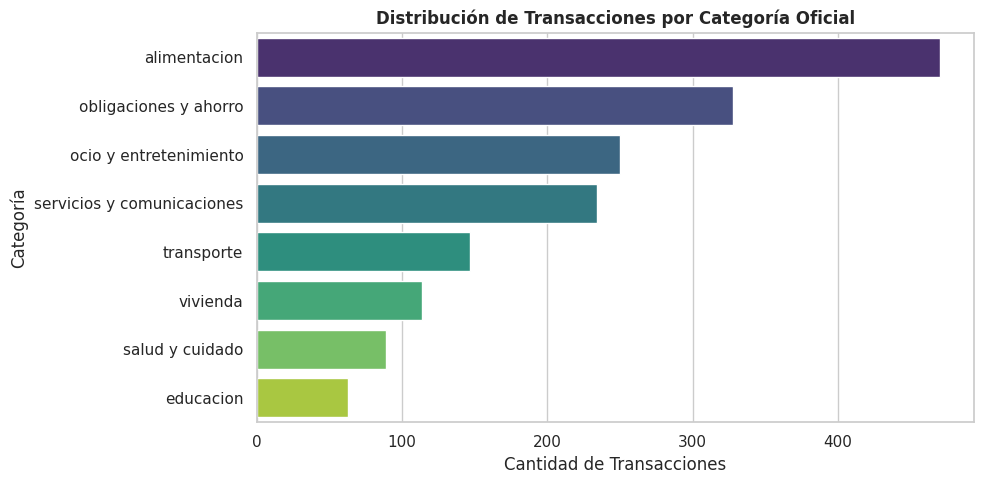

In [16]:
# [5] Visualización 1: Distribución de transacciones por categoría
plt.figure(figsize=(10, 5))
cat_counts = df_final['Categoria_Oficial'].value_counts()
ax = sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette='viridis', legend=False)
plt.title('Distribución de Transacciones por Categoría Oficial', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Transacciones')
plt.ylabel('Categoría')
plt.tight_layout()
plt.savefig('eda_distribucion_categorias_vinah.png', dpi=150)
plt.show()

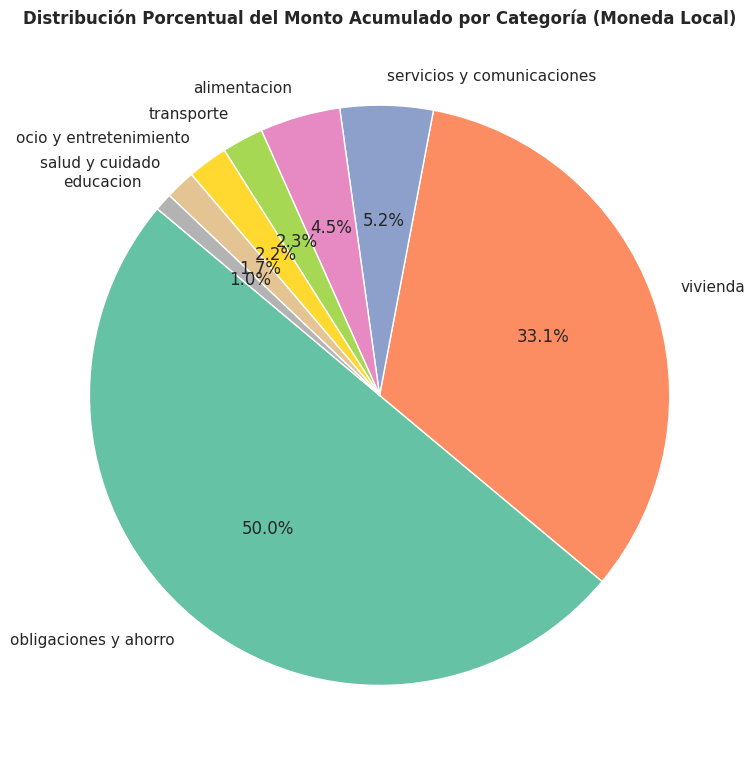

In [17]:
# [6] Visualización 2: Distribución del gasto total acumulado
plt.figure(figsize=(8, 8))
monto_cat = df_final.groupby('Categoria_Oficial')['Monto_Local_ARS'].sum().sort_values(ascending=False)
plt.pie(monto_cat, labels=monto_cat.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2', len(monto_cat)))
plt.title('Distribución Porcentual del Monto Acumulado por Categoría (Moneda Local)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

 **2: Entrenamiento del modelo de MACHINE LEARNING**

##El Tipo de Análisis: Clasificación de Texto Supervisada (NLP)
Lo que implementamos es un problema clásico de Procesamiento de Lenguaje Natural (NLP) y Aprendizaje Supervisado llamado Clasificación de Texto Multiclase (ya que clasificamos cada descripción en una de varias categorías posibles: Comida, Transporte, Servicios, etc.).

El flujo de trabajo (PIPELINE) que diseñamos en el código consta de dos pasos fundamentales que se ejecutan en secuencia:

1. Extracción de Características: Representación de Texto (TF-IDF Vectorizer)
Las computadoras no entienden palabras, solo números. Por lo tanto, el primer paso es convertir el texto de las descripciones en un vector numérico.

Para esto usamos TF-IDF (Term Frequency - Inverse Document Frequency) a través de TfidfVectorizer:

Term Frequency (TF): Mide qué tan frecuente es una palabra en una descripción (por ejemplo, la palabra "farmacia" en "pastillas farmacia").

Inverse Document Frequency (IDF): Reduce el peso de las palabras que aparecen en casi todas las transacciones y que no aportan información diferenciadora (como conectores: "de", "la", "en").

N-gramas (ngram_range=(1, 2)): Le indicamos al modelo que no solo analice palabras sueltas (unigramas), sino también combinaciones de dos palabras juntas (bigramas), como "prime video" o "curso online". Esto ayuda a capturar mucho mejor el contexto.

2. El Algoritmo de Clasificación: SVM Lineal / Descenso de Gradiente Estocástico (SGDClassifier)
Como clasificador, utilizamos el SGDClassifier de Scikit-Learn configurado con una función de pérdida "hinge" (loss='hinge').

Esto equivale matemáticamente a entrenar un modelo de Máquinas de Vectores de Soporte Lineal (Linear Support Vector Machines - SVM).

¿Por qué este algoritmo? Las SVM lineales son extremadamente rápidas, eficientes en memoria y son el estándar de la industria para la clasificación de texto. Al tener un dataset de texto donde la cantidad de palabras (características numéricas creadas por TF-IDF) suele ser muy alta, los modelos lineales como SVM funcionan infinitamente mejor y más rápido que algoritmos como Árboles de Decisión o Random Forests.

In [18]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# 1. Variables de entrada y objetivo
X = df_final[['Descripcion_Limpia', 'Monto_Local_ARS']]
y = df_final['Categoria_Oficial']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Preprocesador (Texto a nivel caracteres + Escala de Monto)
preprocesador = ColumnTransformer(
    transformers=[
        ('texto', TfidfVectorizer(
            analyzer='char_wb',   # Tolera abreviaturas y erratas
            ngram_range=(3, 5),
            strip_accents='unicode',
            lowercase=True
        ), 'Descripcion_Limpia'),

        ('monto', StandardScaler(), ['Monto_Local_ARS'])
    ]
)

# 3. Pipeline final
pipeline_final = Pipeline([
    ('preprocesador', preprocesador),
    ('clasificador', SGDClassifier(
        loss='log_loss',          # Permite calcular probabilidades (predict_proba)
        penalty='l2',
        alpha=1e-4,
        class_weight='balanced', # Corrige el sesgo hacia "alimentacion"
        random_state=42
    ))
])

# 4. Entrenar y evaluar
pipeline_final.fit(X_train, y_train)

y_pred = pipeline_final.predict(X_test)
print("================ REPORTE DE CLASIFICACIÓN ================")
print(classification_report(y_test, y_pred))

# 5. Guardar el archivo .pkl
joblib.dump(pipeline_final, 'modelo_clasificador_gastos.pkl')
print("\n¡Archivo 'modelo_clasificador_gastos.pkl' generado con éxito!")

================ REPORTE DE CLASIFICACIÓN ================
                            precision    recall  f1-score   support

              alimentacion       0.99      0.99      0.99        94
                 educacion       1.00      1.00      1.00        12
     obligaciones y ahorro       1.00      1.00      1.00        66
    ocio y entretenimiento       0.91      0.98      0.94        50
           salud y cuidado       1.00      1.00      1.00        18
servicios y comunicaciones       1.00      0.91      0.96        47
                transporte       1.00      1.00      1.00        29
                  vivienda       1.00      1.00      1.00        23

                  accuracy                           0.98       339
                 macro avg       0.99      0.99      0.99       339
              weighted avg       0.98      0.98      0.98       339


¡Archivo 'modelo_clasificador_gastos.pkl' generado con éxito!


**3:Evaluacion y Exportacion del Modelo**

##Serializacion del modelo y obtencion del archivo .pkl

In [19]:
from google.colab import files

# Descarga directa del archivo limpio a tu computadora
files.download("modelo_clasificador_gastos.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 🗺️ EL VIAJE DEL DATO: Desde la Ingesta hasta el JSON

1. **Ingesta de Datos (La Materia Prima):** Petición API o CSV.
   El viaje comienza cuando el usuario sube un archivo CSV, un extracto bancario o envía un JSON a nuestra API. En este punto, los datos están "crudos" (ej. "Compra en Coto 123" y $420).

2. **Preprocesamiento (Preparar el terreno):** Limpieza y Normalización.
   Antes de que la IA procese la información, Python (con Pandas) limpia el texto (minúsculas, remoción de caracteres). Aquí actúa el **TF-IDF Vectorizer**: traduce esas palabras a vectores numéricos según su importancia.

3. **Inferencia del Modelo (¡Aquí actúa la IA!):** Predicción de Categorías.
   El clasificador (`.pkl`) recibe los vectores del paso anterior. Analiza el patrón léxico (sin mirar montos) y determina la categoría correspondiente mediante el modelo entrenado.

4. **Lógica de Negocio (El Evaluador):** Métricas y Reglas Financieras.
   Con las transacciones clasificadas, la función `analizar_salud_financiera` agrupa los gastos, calcula ratios respecto al ingreso mensual, evalúa endeudamiento y asigna el perfil de riesgo con sus recomendaciones.

5. **Salida Estructurada (El Producto Final):** Formato JSON.
   Todo el conocimiento procesado se empaqueta en una estructura JSON limpia para ser enviada a la aplicación móvil, web o base de datos.

 **4: (La parte de prueba/backend): Prueba de Inferencia / Simulación de Endpoints API**

In [20]:
# Motor Experto Multi-Deuda y Recomendaciones Contextualizadas
def generar_recomendaciones_personalizadas(perfil, score_riesgo, ingreso_local, endeudamiento, frecuencia_ahorro, resumen_gastos, total_gastado, ratio_gasto, m_local):
    recomendaciones = []

    cat_dominante = max(resumen_gastos, key=resumen_gastos.get) if total_gastado > 0 else 'ocio y entretenimiento'
    monto_cat = resumen_gastos.get(cat_dominante, 0.0)
    pct_cat = round((monto_cat / total_gastado * 100), 1) if total_gastado > 0 else 0.0

    end_num = float(endeudamiento)
    ratio_num = round(float(ratio_gasto), 1)

    monto_obligaciones = resumen_gastos.get('obligaciones y ahorro', 0.0)
    monto_vivienda = resumen_gastos.get('vivienda', 0.0)
    monto_transporte = resumen_gastos.get('transporte', 0.0)

    if perfil == 'En riesgo':
        if end_num > 40:
            if monto_obligaciones > 0:
                recomendaciones.append(f'⚠️ Nivel de deuda elevado ({end_num}%): Revisa compromisos de préstamos personales, tarjetas o créditos bancarios ({monto_obligaciones:,.0f} {m_local}). Consolida pasivos para reducir cuotas.')
            elif monto_vivienda > 0:
                recomendaciones.append(f'⚠️ Tu crédito hipotecario/alquiler representa {monto_vivienda:,.0f} {m_local}. Evita asumir nuevos compromisos o préstamos mientras regularizas tu presupuesto.')
            else:
                recomendaciones.append(f'⚠️ Nivel de endeudamiento elevado del {end_num}%. Prioriza cancelar deudas pendientes con préstamos o terceros.')
        elif ratio_num > 80:
            recomendaciones.append(f'🚨 Tus gastos representan el {ratio_num}% de tus ingresos. Es urgente congelar nuevos créditos y recortar compras en {cat_dominante} ({monto_cat:,.0f} {m_local}).')
        else:
            recomendaciones.append(f'⚠️ Riesgo financiero elevado. Reduce egresos en la categoría principal "{cat_dominante}" ({pct_cat}% del total).')

        if str(frecuencia_ahorro).lower() in ['baja', 'ninguna', '0']:
            recomendaciones.append('Construye un fondo de reserva de emergencia antes de solicitar préstamos adicionales.')
        else:
            recomendaciones.append(f'Limita compras en la categoría {cat_dominante} para recuperar tu superávit mensual.')

    elif perfil == 'En observacion':
        if end_num >= 25:
            if monto_vivienda > monto_obligaciones and monto_vivienda > 0:
                recomendaciones.append(f'💡 Tu cuota de vivienda/préstamo del hogar ({monto_vivienda:,.0f} {m_local}) absorbe parte importante de tus ingresos. Mantén acotados los préstamos personales.')
            elif monto_transporte > 0 and cat_dominante == 'transporte':
                recomendaciones.append(f'💡 Los gastos de vehículo/cuota de transporte representan {monto_transporte:,.0f} {m_local}. Revisa gastos asociados como seguro o mantenimiento.')
            else:
                recomendaciones.append(f'💡 Tu nivel de endeudamiento es del {end_num}%. Limita el uso de tarjeta de crédito o la solicitud de préstamos a plazo.')
        elif cat_dominante in ['ocio y entretenimiento', 'alimentacion'] and pct_cat > 30:
            recomendaciones.append(f'💡 La categoría "{cat_dominante}" representa el {pct_cat}% de tus gastos ({monto_cat:,.0f} {m_local}). Fija un límite semanal para compras discretas.')
        else:
            recomendaciones.append(f'💡 Tus gastos suman el {ratio_num}% de tus ingresos. Controla pequeños consumos en {cat_dominante}.')

        if str(frecuencia_ahorro).lower() in ['baja', 'media']:
            recomendaciones.append('Automatiza la transferencia del 10% de tus ingresos a un fondo de ahorro apenas cobres tu sueldo.')
        else:
            recomendaciones.append(f'Monitorea la categoría {cat_dominante} para evitar pasar al perfil de riesgo.')

    else:  # Perfil Saludable
        recomendaciones.append(f'✅ ¡Excelente salud financiera! Mantienes tus gastos en un {ratio_num}% de tus ingresos y compromisos crediticios sostenibles ({end_num}%).')
        if pct_cat > 0:
            recomendaciones.append(f'📈 Con tu capacidad de ahorro actual, explora herramientas como Fondos Comunes o Plazos Fijos para hacer crecer tu capital excedente.')

    return recomendaciones[:2]

##Funcion Principal de Inferencia para Backend API

In [21]:
# Función Principal de Inferencia para Backend API
def analizar_salud_financiera(ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, transacciones, modelo, moneda_local_usuario='ARS'):
    try:
        m_local = str(moneda_local_usuario).upper().strip()
        descripciones_limpias = [normalizar_texto_gasto(t.get('descripcion', '')) for t in transacciones]

        try:
            categorias_predichas = modelo.predict(descripciones_limpias)
        except Exception:
            categorias_predichas = ['ocio y entretenimiento'] * len(descripciones_limpias)

        detalles_transacciones = []
        valores_locales = []

        for t, cat_pred in zip(transacciones, categorias_predichas):
            m_orig_val = float(t.get('valor', 0.0))
            m_orig_curr = str(t.get('moneda', 'USD')).upper()
            m_local_val, tasa = convertir_divisa(m_orig_val, m_orig_curr, m_local)

            valores_locales.append(m_local_val)
            detalles_transacciones.append({
                'descripcion_original': t.get('descripcion', ''),
                'categoria_asignada': cat_pred,
                'monto_original': round(m_orig_val, 2),
                'moneda_original': m_orig_curr,
                'monto_local_convertido': round(m_local_val, 2),
                'moneda_local_usuario': m_local,
                'tasa_cambio_aplicada': tasa
            })

        resumen_gastos = {
            'vivienda': 0.0,
            'servicios y comunicaciones': 0.0,
            'alimentacion': 0.0,
            'transporte': 0.0,
            'salud y cuidado': 0.0,
            'educacion': 0.0,
            'ocio y entretenimiento': 0.0,
            'obligaciones y ahorro': 0.0
        }

        total_gastado = 0.0
        for cat_pred, val in zip(categorias_predichas, valores_locales):
            if cat_pred in resumen_gastos:
                resumen_gastos[cat_pred] = round(resumen_gastos[cat_pred] + val, 2)
            else:
                resumen_gastos['ocio y entretenimiento'] = round(resumen_gastos.get('ocio y entretenimiento', 0.0) + val, 2)
            total_gastado += val

        ingreso_local_val, _ = convertir_divisa(ingreso_mensual, 'USD', m_local) if float(ingreso_mensual) < 10000 else (float(ingreso_mensual), 1.0)
        ratio_gasto = ((total_gastado / ingreso_local_val) * 100) if ingreso_local_val > 0 else 0.0

        score_riesgo = 0
        end_num = float(nivel_endeudamiento)
        if end_num > 40: score_riesgo += 40
        elif end_num > 25: score_riesgo += 25
        else: score_riesgo += 5

        if ratio_gasto > 80: score_riesgo += 40
        elif ratio_gasto > 50: score_riesgo += 20
        else: score_riesgo += 5

        frecuencias = {'baja': 20, 'media': 10, 'alta': 0}
        score_riesgo += frecuencias.get(str(frecuencia_ahorro).lower(), 10)

        if score_riesgo >= 60:
            perfil = 'En riesgo'
            prob = round(min(score_riesgo / 100.0, 0.99), 2)
        elif score_riesgo >= 30:
            perfil = 'En observacion'
            prob = round(score_riesgo / 100.0, 2)
        else:
            perfil = 'Saludable'
            prob = round(1.0 - (score_riesgo / 100.0), 2)

        recomendaciones = generar_recomendaciones_personalizadas(
            perfil=perfil,
            score_riesgo=score_riesgo,
            ingreso_local=ingreso_local_val,
            endeudamiento=end_num,
            frecuencia_ahorro=frecuencia_ahorro,
            resumen_gastos=resumen_gastos,
            total_gastado=total_gastado,
            ratio_gasto=ratio_gasto,
            m_local=m_local
        )

        return {
            'perfil_financiero': perfil,
            'probabilidad_riesgo': prob,
            'moneda_local_usuario': m_local,
            'resumen_gastos_por_categoria': resumen_gastos,
            'total_gastado_local': round(total_gastado, 2),
            'ratio_gasto_ingreso_pct': round(ratio_gasto, 2),
            'recomendaciones': recomendaciones,
            'detalles_transacciones_procesadas': detalles_transacciones
        }
    except Exception as general_error:
        return {
            'perfil_financiero': 'En observacion',
            'probabilidad_riesgo': 0.5,
            'moneda_local_usuario': moneda_local_usuario,
            'resumen_gastos_por_categoria': {c: 0.0 for c in ['vivienda', 'servicios y comunicaciones', 'alimentacion', 'transporte', 'salud y cuidado', 'educacion', 'ocio y entretenimiento', 'obligaciones y ahorro']},
            'total_gastado_local': 0.0,
            'ratio_gasto_ingreso_pct': 0.0,
            'recomendaciones': ['Revisa las transacciones ingresadas.', 'Automatiza tu ahorro mensual.'],
            'detalles_transacciones_procesadas': []
        }

##Prueba de ejecucion

**Nota de Integración**: Esta sección demuestra la carga del archivo .pkl generado y simula/valida la respuesta que procesará el servicio api.py (FastAPI) para enviar las predicciones a la interfaz visual.

In [22]:
# Prueba de ejecución
ejemplo_json_prueba = {
    'ingreso_mensual': 1200.0,
    'nivel_endeudamiento': 45.0,
    'frecuencia_ahorro': 'Baja',
    'moneda_local_usuario': 'COP',
    'transacciones': [
        {'descripcion': '🏦 Pago cuota prestamo bancario', 'valor': 450000.0, 'moneda': 'COP'},
        {'descripcion': '🛒 SUPERMERCADO EXITO compras', 'valor': 200000.0, 'moneda': 'COP'}
    ]
}

res = analizar_salud_financiera(
    ingreso_mensual=ejemplo_json_prueba['ingreso_mensual'],
    nivel_endeudamiento=ejemplo_json_prueba['nivel_endeudamiento'],
    frecuencia_ahorro=ejemplo_json_prueba['frecuencia_ahorro'],
    transacciones=ejemplo_json_prueba['transacciones'],
    modelo=pipeline_final,
    moneda_local_usuario=ejemplo_json_prueba['moneda_local_usuario']
)

print('\n=== PRUEBA DE RESPUESTA JSON MULTI-DEUDA ===')
print(json.dumps(res, indent=2, ensure_ascii=False))


=== PRUEBA DE RESPUESTA JSON MULTI-DEUDA ===
{
  "perfil_financiero": "En riesgo",
  "probabilidad_riesgo": 0.65,
  "moneda_local_usuario": "COP",
  "resumen_gastos_por_categoria": {
    "vivienda": 0.0,
    "servicios y comunicaciones": 0.0,
    "alimentacion": 0.0,
    "transporte": 0.0,
    "salud y cuidado": 0.0,
    "educacion": 0.0,
    "ocio y entretenimiento": 650000.0,
    "obligaciones y ahorro": 0.0
  },
  "total_gastado_local": 650000.0,
  "ratio_gasto_ingreso_pct": 13.54,
  "recomendaciones": [
    "⚠️ Nivel de endeudamiento elevado del 45.0%. Prioriza cancelar deudas pendientes con préstamos o terceros.",
    "Construye un fondo de reserva de emergencia antes de solicitar préstamos adicionales."
  ],
  "detalles_transacciones_procesadas": [
    {
      "descripcion_original": "🏦 Pago cuota prestamo bancario",
      "categoria_asignada": "ocio y entretenimiento",
      "monto_original": 450000.0,
      "moneda_original": "COP",
      "monto_local_convertido": 450000.0,
  

##Matriz de confusion

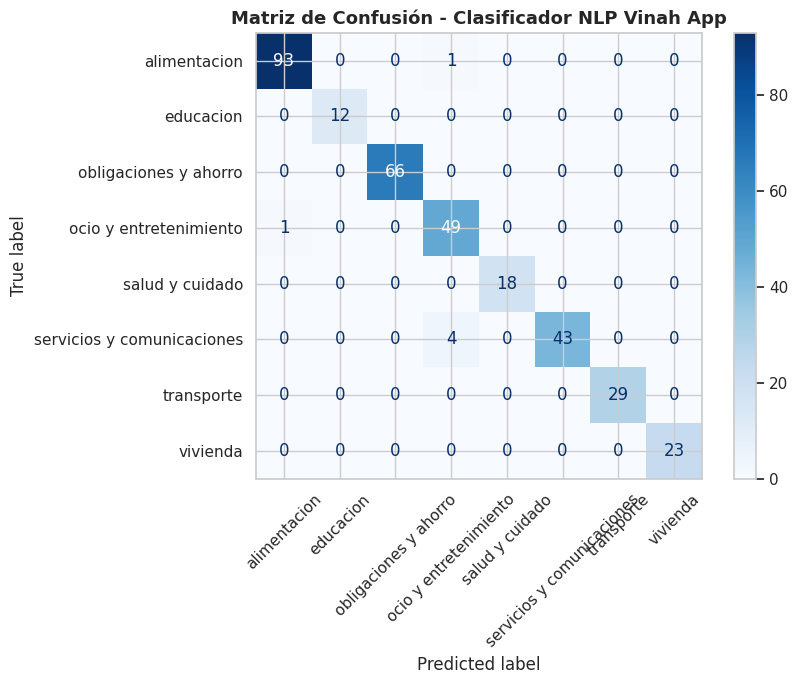

In [23]:
#  Visualización 3: Matriz de confusión del clasificador
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred, labels=pipeline_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline_final.classes_)
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d', ax=ax)
plt.title('Matriz de Confusión - Clasificador NLP Vinah App', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Comentario de interpretación técnica de la matriz
"""
📌 CÓMO INTERPRETAR ESTA MATRIZ DE CONFUSIÓN:

1. Diagonal Principal (Aciertos):
   - Cada celda en la diagonal (de arriba a la izquierda a abajo a la derecha) representa el número
     de transacciones clasificadas CORRECTAMENTE por el modelo.
   - Mientras mayores sean los valores de esta diagonal (colores más intensos), mayor es la
     precisión del clasificador en esa categoría.

2. Fuera de la Diagonal (Errores / Confusiones):
   - Las celdas fuera de la diagonal muestran los casos donde el modelo se equivocó.
   - Filas = Categoría Real / Columnas = Categoría Predicha.
   - Ejemplo: Si hay un valor elevado en la intersección de la fila 'transporte' y la columna
     'ocio y entretenimiento', significa que el modelo tendió a confundir gastos de transporte
     con actividades de ocio (por ej., por palabras compartidas en las descripciones).

3. Diagnóstico del Pipeline:
   - Una diagonal marcada confirma que el vectorizador TF-IDF y el algoritmo SVM lograron
     separar adecuadamente los patrones semánticos de cada tipo de gasto.
"""

"\n📌 CÓMO INTERPRETAR ESTA MATRIZ DE CONFUSIÓN:\n\n1. Diagonal Principal (Aciertos):\n   - Cada celda en la diagonal (de arriba a la izquierda a abajo a la derecha) representa el número \n     de transacciones clasificadas CORRECTAMENTE por el modelo.\n   - Mientras mayores sean los valores de esta diagonal (colores más intensos), mayor es la \n     precisión del clasificador en esa categoría.\n\n2. Fuera de la Diagonal (Errores / Confusiones):\n   - Las celdas fuera de la diagonal muestran los casos donde el modelo se equivocó.\n   - Filas = Categoría Real / Columnas = Categoría Predicha.\n   - Ejemplo: Si hay un valor elevado en la intersección de la fila 'transporte' y la columna \n     'ocio y entretenimiento', significa que el modelo tendió a confundir gastos de transporte \n     con actividades de ocio (por ej., por palabras compartidas en las descripciones).\n\n3. Diagnóstico del Pipeline:\n   - Una diagonal marcada confirma que el vectorizador TF-IDF y el algoritmo SVM lograron

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Usamos las variables que ya existen en tu cuaderno
# Reemplaza 'y_test' e 'y_pred' si en tu código se llaman distinto (ej: y_eval, predicciones)
cm = confusion_matrix(y_test, y_pred)

aciertos_totales = np.trace(cm)
errores_totales = np.sum(cm) - aciertos_totales
precision_global = (aciertos_totales / np.sum(cm)) * 100

print(f"📊 INTERPRETACIÓN DEL GRÁFICO:")
print(f"• De {np.sum(cm)} transacciones de prueba, el modelo clasificó correctamente {aciertos_totales} ({precision_global:.1f}%).")
print(f"• Se detectaron {errores_totales} clasificaciones erróneas fuera de la diagonal principal.")

📊 INTERPRETACIÓN DEL GRÁFICO:
• De 339 transacciones de prueba, el modelo clasificó correctamente 333 (98.2%).
• Se detectaron 6 clasificaciones erróneas fuera de la diagonal principal.
